# CNN Image Classification: Cats vs Dogs

Steps:
1. Dataset preparation (from Google Drive)
2. Google Drive connection
3. Reading and displaying images
4. File extension filtering
5. Dataset creation via `image_dataset_from_directory`
6. Numpy iterator
7. Normalisation
8. Train/val/test split
9. CNN architecture
10. Training and evaluation

## Step 0. Imports

In [ ]:
import os
import zipfile
import shutil
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from pathlib import Path

print(f'TensorFlow: {tf.__version__}')
print(f'GPU: {tf.config.list_physical_devices("GPU")}')

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Step 1. Dataset preparation

Dataset is stored on Google Drive under `Neural Networks/`:
- `Neural Networks/Cats/` — zip archive with cat images
- `Neural Networks/Dogs/` — zip archive with dog images

Mount Drive and extract archives into `/content/dataset/`.

In [ ]:
import os
import zipfile
import shutil
from pathlib import Path
from google.colab import drive

drive.mount('/content/drive')

DRIVE_BASE  = Path('/content/drive/MyDrive/Neural Networks')
DATASET_DIR = Path('/content/dataset')

if DATASET_DIR.exists():
    shutil.rmtree(DATASET_DIR)

for cls in ['cats', 'dogs']:
    dest = DATASET_DIR / cls
    dest.mkdir(parents=True, exist_ok=True)

    zips = list((DRIVE_BASE / cls.capitalize()).glob('*.zip'))

    if not zips:
        print(f'no zip found for {cls}')
        continue

    with zipfile.ZipFile(zips[0], 'r') as z:
        z.extractall(dest)

    for sub in [p for p in dest.iterdir() if p.is_dir()]:
        for img in sub.iterdir():
            img.rename(dest / img.name)
        sub.rmdir()

    print(f'{cls}: {len(list(dest.glob("*.*")))} images')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
cats: 519 images
dogs: 530 images


## Step 2. Google Drive

Drive is mounted in Step 1.

In [ ]:
print(f'DATASET_DIR: {DATASET_DIR}')
print(f'cats: {len(list((DATASET_DIR / "cats").glob("*.*")))} files')
print(f'dogs: {len(list((DATASET_DIR / "dogs").glob("*.*")))} files')

DATASET_DIR: /content/dataset
cats: 519 files
dogs: 530 files


## Steps 3-4. Reading and displaying images

file:  image (24).jpeg
shape: (185, 272, 3)
dtype: uint8
range: 0 - 255


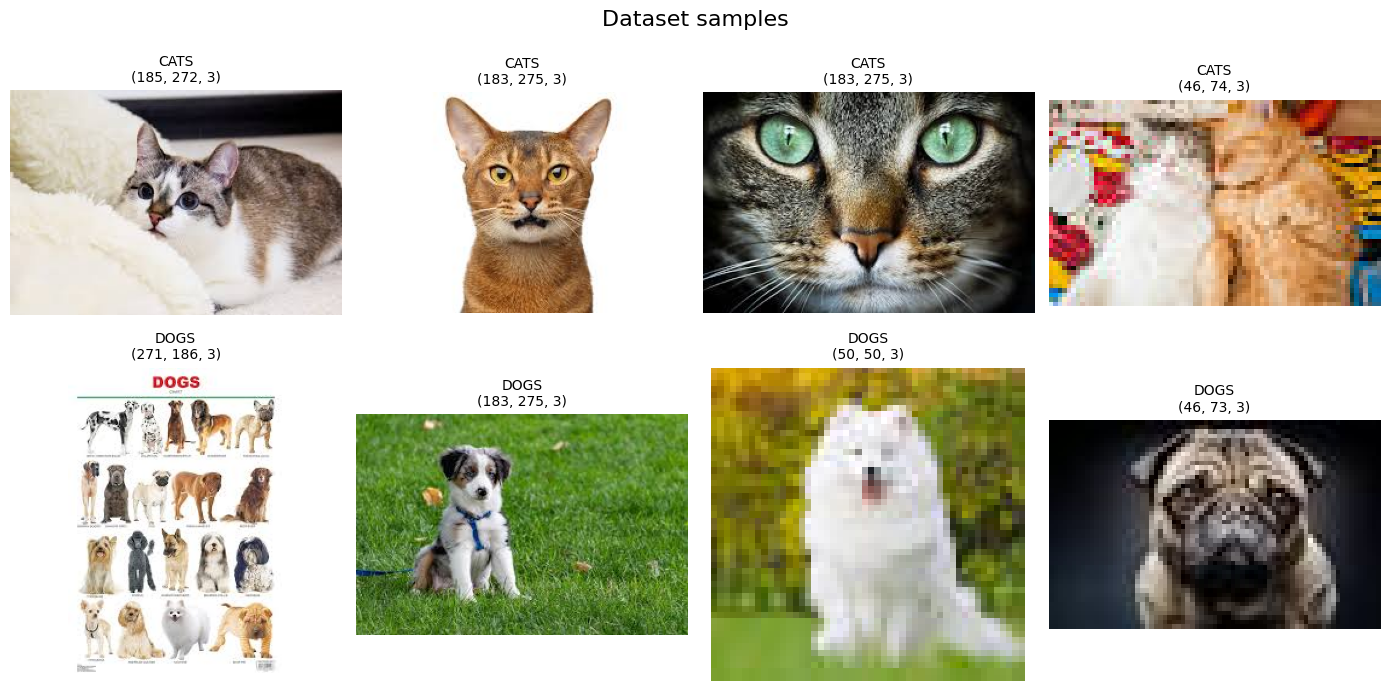

In [ ]:
VALID_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.bmp', '.JPG', '.JPEG')
sample_cats = [p for p in (DATASET_DIR / 'cats').iterdir() if p.suffix in VALID_EXTENSIONS]

if not sample_cats:
    print('Error: No images found in the cats folder. Check your file extensions.')
else:
    sample_path = sample_cats[0]
    sample_img  = mpimg.imread(str(sample_path))
    print(f'file:  {sample_path.name}')
    print(f'shape: {sample_img.shape}')
    print(f'dtype: {sample_img.dtype}')
    print(f'range: {sample_img.min()} - {sample_img.max()}')

    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    fig.suptitle('Dataset samples', fontsize=16)

    for row, cls in enumerate(['cats', 'dogs']):
        images = [p for p in (DATASET_DIR / cls).iterdir() if p.suffix in VALID_EXTENSIONS][:4]
        for col in range(4):
            ax = axes[row, col]
            if col < len(images):
                img = mpimg.imread(str(images[col]))
                ax.imshow(img)
                ax.set_title(f'{cls.upper()}\n{img.shape}', fontsize=10)
            ax.axis('off')

    plt.tight_layout()
    plt.show()

## Step 5. File extension filtering

In [ ]:
ALLOWED_EXTENSIONS = {'jpeg', 'jpg', 'bmp', 'png'}

removed     = 0
kept        = 0
ext_counter = {}

for cls in ['cats', 'dogs']:
    for f in list((DATASET_DIR / cls).glob('*')):
        if not f.is_file():
            continue
        ext = f.suffix.lower().lstrip('.')
        ext_counter[ext] = ext_counter.get(ext, 0) + 1
        if ext not in ALLOWED_EXTENSIONS:
            f.unlink()
            removed += 1
        else:
            kept += 1

print(f'extensions: {ext_counter}')
print(f'kept: {kept}, removed: {removed}')

extensions: {'jpeg': 1049}
kept: 1049, removed: 0


## Step 6. Dataset via `image_dataset_from_directory`

In [ ]:
IMG_SIZE   = (128, 128)
BATCH_SIZE = 8
SEED       = 42

full_dataset = tf.keras.utils.image_dataset_from_directory(
    str(DATASET_DIR),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
    label_mode='binary'
)

class_names = full_dataset.class_names
print(f'classes: {class_names}')
print(f'batches: {len(full_dataset)}')

for images, labels in full_dataset.take(1):
    print(f'images: {images.shape}')
    print(f'labels: {labels.shape}')
    print(f'unique labels: {tf.unique(tf.squeeze(tf.cast(labels, tf.int32))).y.numpy()}')

Found 1049 files belonging to 2 classes.
classes: ['cats', 'dogs']
batches: 132
images: (8, 128, 128, 3)
labels: (8, 1)
unique labels: [1 0]


## Step 7. Numpy iterator

shape: (8, 128, 128, 3)
dtype: float32
range: [0.0, 255.0]
first 8 labels: [1 0 0 1 0 1 1 0]
(0=cats, 1=dogs)


/tmp/ipykernel_4450/2482164626.py:15: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ax.set_title(class_names[int(labels_np[i])], fontsize=11)


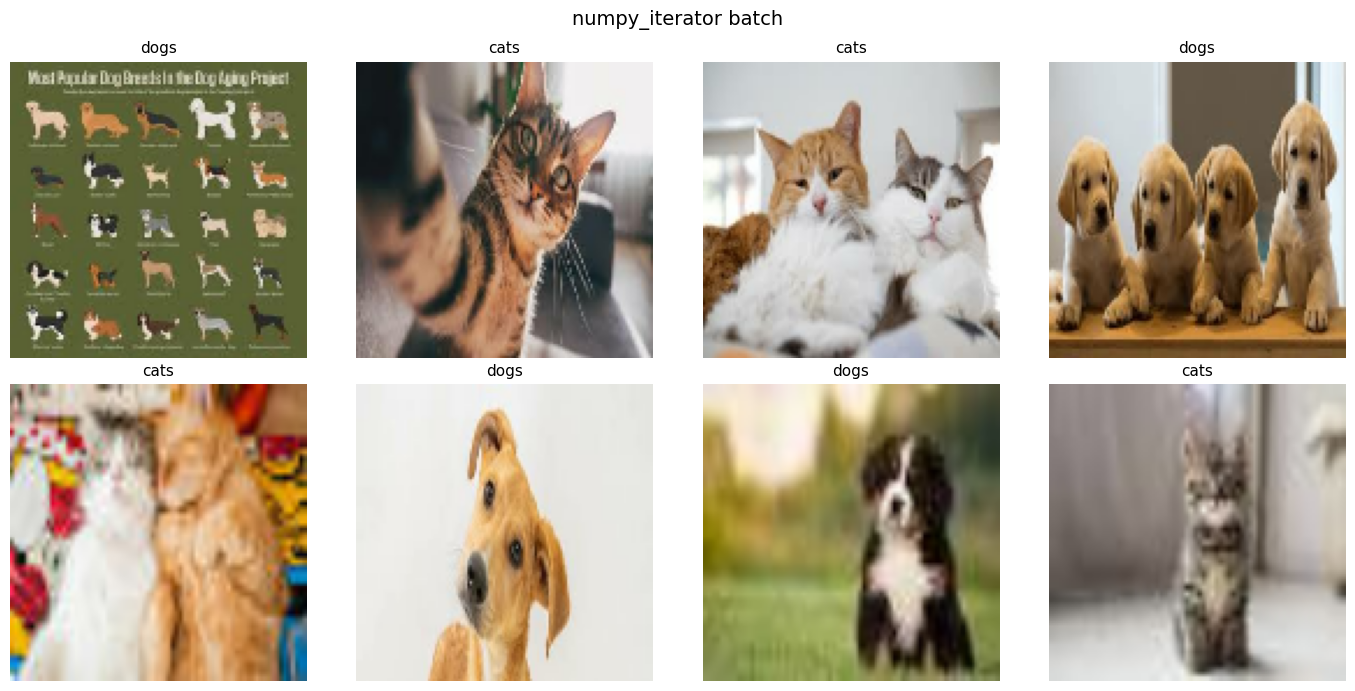

In [ ]:
numpy_iter  = full_dataset.as_numpy_iterator()
first_batch = next(numpy_iter)
images_np, labels_np = first_batch

print(f'shape: {images_np.shape}')
print(f'dtype: {images_np.dtype}')
print(f'range: [{images_np.min():.1f}, {images_np.max():.1f}]')
print(f'first 8 labels: {labels_np[:8].flatten().astype(int)}')
print(f'(0={class_names[0]}, 1={class_names[1]})')

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle('numpy_iterator batch', fontsize=14)
for i, ax in enumerate(axes.flat):
    ax.imshow(images_np[i].astype('uint8'))
    ax.set_title(class_names[int(labels_np[i])], fontsize=11)
    ax.axis('off')
plt.tight_layout()
plt.show()

## Step 8. Normalisation

min=0.0000  max=1.0000  mean=0.4403


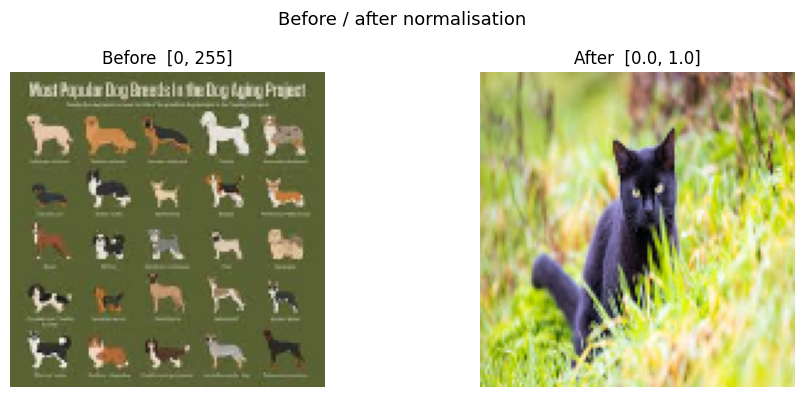

In [ ]:
normalization_layer = layers.Rescaling(1.0 / 255)

normalized_dataset = full_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

augmentation_layer = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name='augmentation')

for images_norm, labels in normalized_dataset.take(1):
    arr = images_norm.numpy()
    print(f'min={arr.min():.4f}  max={arr.max():.4f}  mean={arr.mean():.4f}')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Before / after normalisation', fontsize=13)

axes[0].imshow(images_np[0].astype('uint8'))
axes[0].set_title('Before  [0, 255]')
axes[0].axis('off')

axes[1].imshow(images_norm.numpy()[0])
axes[1].set_title('After  [0.0, 1.0]')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## Step 9. Train / val / test split

Split: 70% train / 15% validation / 15% test

In [ ]:
total_batches = len(normalized_dataset)

train_size = int(total_batches * 0.70)
val_size   = max(1, int(total_batches * 0.15))
test_size  = max(1, total_batches - train_size - val_size)
train_size = total_batches - val_size - test_size

print(f'total: {total_batches} batches -> train: {train_size}, val: {val_size}, test: {test_size}')

AUTOTUNE = tf.data.AUTOTUNE

normalized_dataset = normalized_dataset.cache().shuffle(
    buffer_size=total_batches, seed=SEED, reshuffle_each_iteration=False
)

train_ds  = normalized_dataset.take(train_size).shuffle(1000, reshuffle_each_iteration=True).map(
    lambda x, y: (augmentation_layer(x, training=True), y), num_parallel_calls=AUTOTUNE
).prefetch(AUTOTUNE)
remaining = normalized_dataset.skip(train_size)
val_ds    = remaining.take(val_size).prefetch(AUTOTUNE)
test_ds   = remaining.skip(val_size).prefetch(AUTOTUNE)

for name, ds in [('train', train_ds), ('val', val_ds), ('test', test_ds)]:
    labels = np.concatenate([y.numpy() for _, y in ds])
    print(f'{name}: {len(labels)} samples | {class_names[0]}={int((labels==0).sum())} {class_names[1]}={int((labels==1).sum())}')

total: 132 batches -> train: 92, val: 19, test: 21
train: 729 samples | cats=360 dogs=369
val: 152 samples | cats=69 dogs=83
test: 168 samples | cats=90 dogs=78


## Step 10. CNN architecture

In [ ]:
model = Sequential([
    layers.Input(shape=(128, 128, 3)),

    layers.Conv2D(32,  (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(64,  (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(128, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(256, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Flatten(),
    layers.Dense(256),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),
    layers.Dense(64),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dense(1, activation='sigmoid'),
], name='CNN_Cats_vs_Dogs')

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "CNN_Cats_vs_Dogs"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 4,602,689 (17.56 MB)

 Trainable params: 4,601,089 (17.55 MB)

 Non-trainable params: 1,600 (6.25 KB)

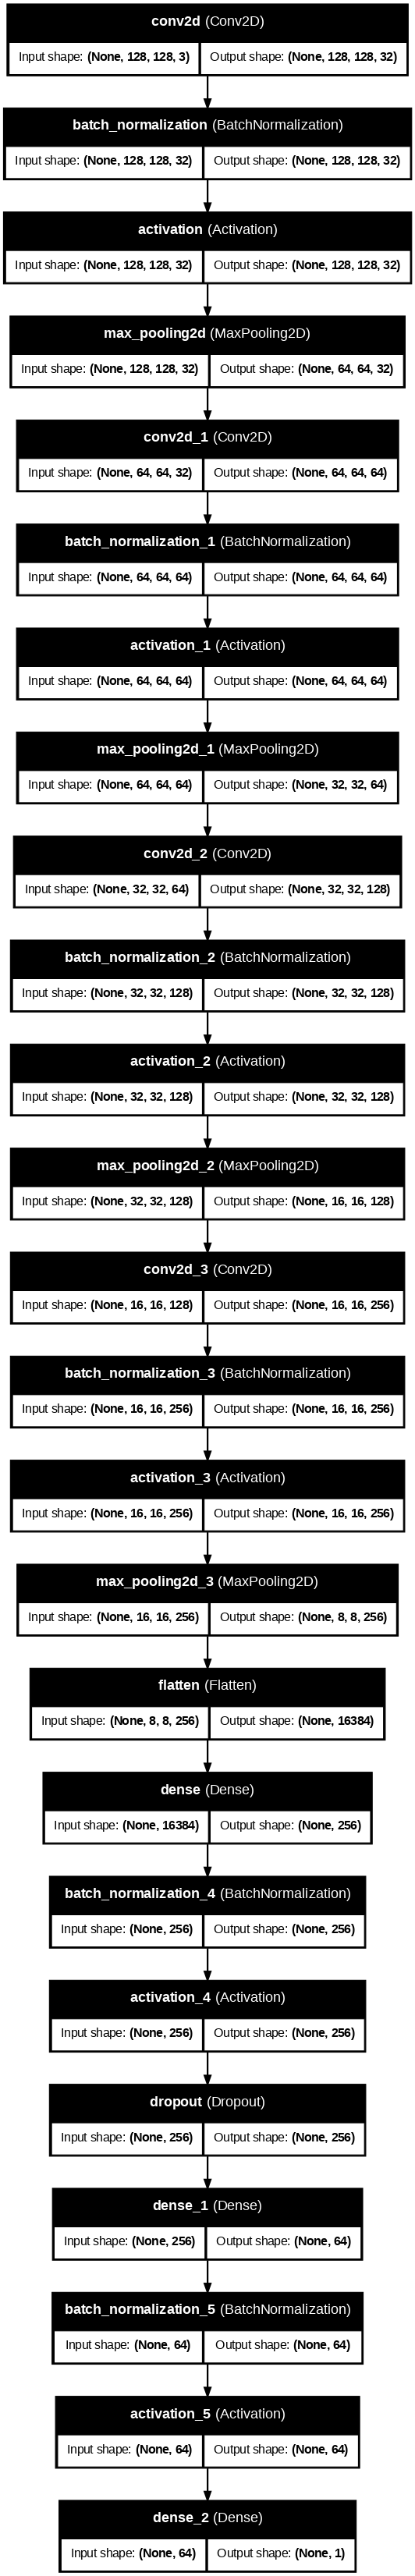

In [ ]:
tf.keras.utils.plot_model(
    model,
    to_file='model_architecture.png',
    show_shapes=True,
    show_layer_names=True,
    dpi=80
)

from IPython.display import Image
Image('model_architecture.png')

## Step 11. Training

In [ ]:
EPOCHS = 15

callbacks = [
    keras.callbacks.ModelCheckpoint(
        'best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        verbose=1
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.5913 - loss: 0.6911
Epoch 1: val_accuracy improved from None to 0.45395, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 90ms/step - accuracy: 0.6584 - loss: 0.6255 - val_accuracy: 0.4539 - val_loss: 0.7555 - learning_rate: 1.0000e-04
Epoch 2/15
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7775 - loss: 0.4562
Epoch 2: val_accuracy improved from 0.45395 to 0.46711, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.7915 - loss: 0.4460 - val_accuracy: 0.4671 - val_loss: 0.7418 - learning_rate: 1.0000e-04
Epoch 3/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.8649 - loss: 0.3562
Epoch 3: val_accuracy improved from 0.46711 to 0.57237, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/s

## Training results

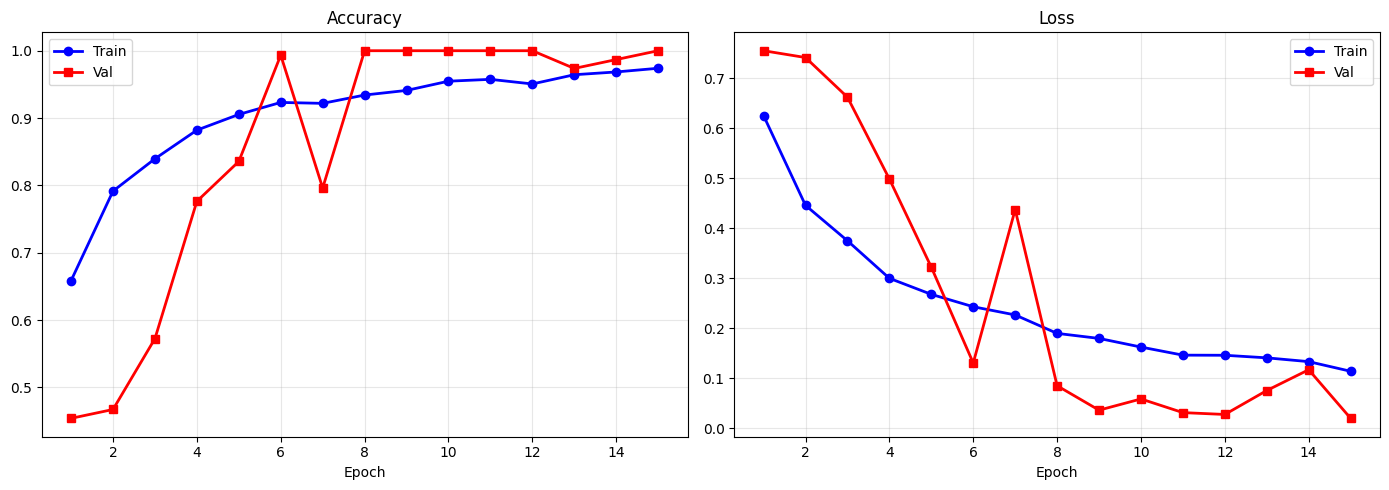

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
history_dict = history.history
epochs_range = range(1, len(history_dict['accuracy']) + 1)

axes[0].plot(epochs_range, history_dict['accuracy'],     'b-o', label='Train', linewidth=2)
if 'val_accuracy' in history_dict:
    axes[0].plot(epochs_range, history_dict['val_accuracy'], 'r-s', label='Val',   linewidth=2)

axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history_dict['loss'],     'b-o', label='Train', linewidth=2)
if 'val_loss' in history_dict:
    axes[1].plot(epochs_range, history_dict['val_loss'], 'r-s', label='Val',   linewidth=2)

axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Evaluation

In [ ]:
test_loss, test_accuracy = model.evaluate(test_ds, verbose=1)
print(f'test accuracy: {test_accuracy * 100:.2f}%  loss: {test_loss:.4f}')

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0256
test accuracy: 100.00%  loss: 0.0256


              precision    recall  f1-score   support

        cats       1.00      1.00      1.00        90
        dogs       1.00      1.00      1.00        78

    accuracy                           1.00       168
   macro avg       1.00      1.00      1.00       168
weighted avg       1.00      1.00      1.00       168



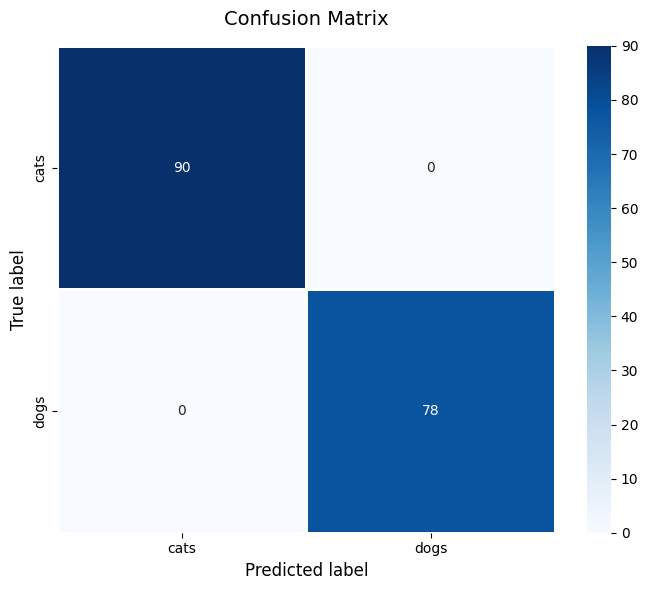

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_true_list = []
y_pred_list = []
images_list = []

for images_batch, labels_batch in test_ds:
    preds = model.predict(images_batch, verbose=0)
    y_pred_list.extend((preds > 0.5).astype(int).flatten())
    y_true_list.extend(labels_batch.numpy().astype(int).flatten())
    images_list.extend(images_batch.numpy())

y_true = np.array(y_true_list)
y_pred = np.array(y_pred_list)

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            ax=ax, linewidths=1, linecolor='white')
ax.set_title('Confusion Matrix', fontsize=14, pad=15)
ax.set_ylabel('True label', fontsize=12)
ax.set_xlabel('Predicted label', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

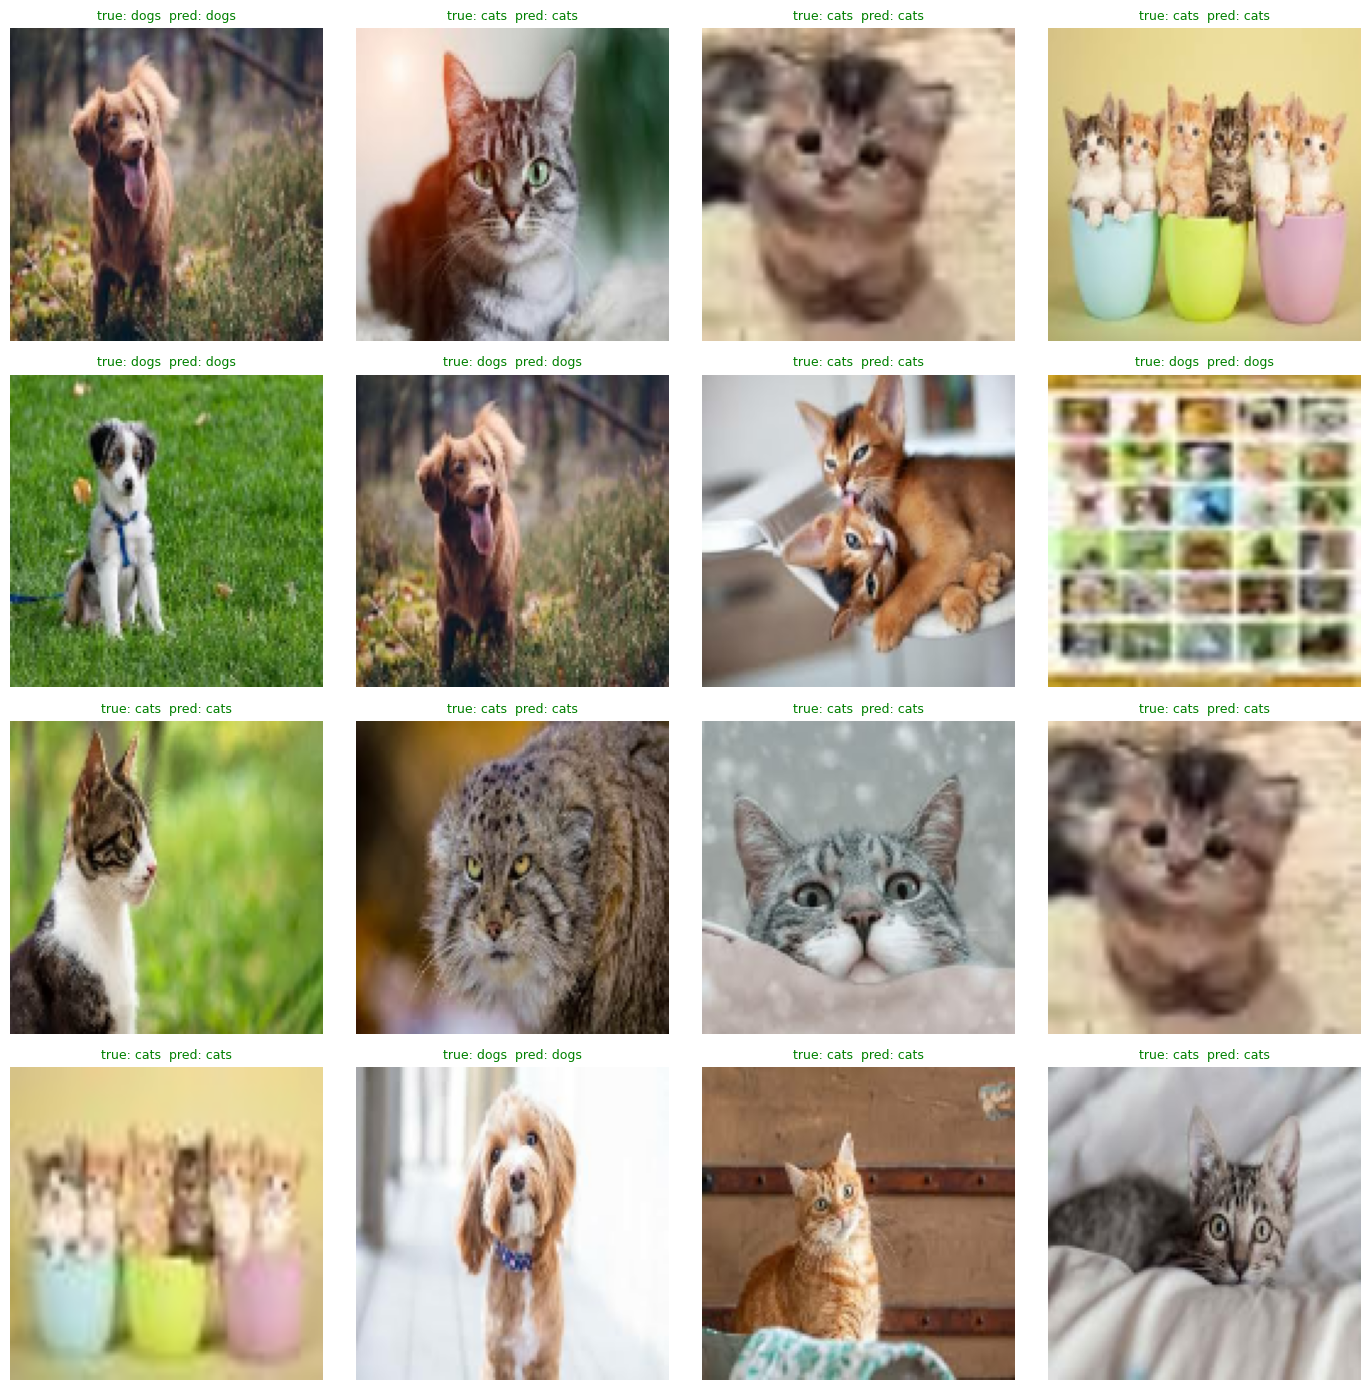

168/168 correct (100.0%)


In [ ]:
n_show      = 16
images_show = np.array(images_list[:n_show])
y_true_show = y_true[:n_show]
y_pred_show = y_pred[:n_show]

fig, axes = plt.subplots(4, 4, figsize=(14, 14))

for i, ax in enumerate(axes.flat):
    ax.imshow(images_show[i])
    true_lbl = class_names[int(y_true_show[i])]
    pred_lbl = class_names[int(y_pred_show[i])]
    correct  = (y_true_show[i] == y_pred_show[i])
    color    = 'green' if correct else 'red'
    ax.set_title(f'true: {true_lbl}  pred: {pred_lbl}', color=color, fontsize=9)
    ax.axis('off')
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(3)
        spine.set_visible(True)

plt.tight_layout()
plt.savefig('predictions.png', dpi=150, bbox_inches='tight')
plt.show()

correct_total = int(np.sum(y_true == y_pred))
total         = len(y_true)
print(f'{correct_total}/{total} correct ({correct_total/total*100:.1f}%)')

## Save model

In [ ]:
model.save('cats_dogs_cnn_model.keras')

## Single image prediction

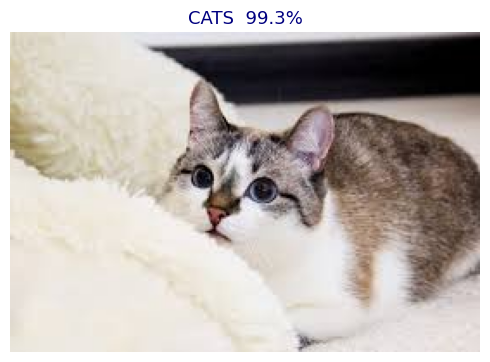

cats (99.3%)


In [ ]:
def predict_image(img_path, model, class_names, img_size=(128, 128)):
    img       = tf.keras.utils.load_img(img_path, target_size=img_size)
    img_array = tf.keras.utils.img_to_array(img) / 255.0
    img_array = tf.expand_dims(img_array, 0)

    prediction = model.predict(img_array, verbose=0)[0][0]
    class_idx  = int(prediction > 0.5)
    confidence = prediction if class_idx == 1 else 1 - prediction

    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    ax.imshow(tf.keras.utils.load_img(img_path))
    ax.set_title(
        f'{class_names[class_idx].upper()}  {confidence * 100:.1f}%',
        fontsize=13, color='navy'
    )
    ax.axis('off')
    plt.tight_layout()
    plt.show()
    return class_names[class_idx], confidence

VALID_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.bmp', '.JPG', '.JPEG')
cats_imgs = [p for p in (DATASET_DIR / 'cats').iterdir() if p.suffix in VALID_EXTENSIONS]

if not cats_imgs:
    raise FileNotFoundError(f'No images found in {DATASET_DIR / "cats"}')

test_img = str(cats_imgs[0])
label, conf = predict_image(test_img, model, class_names)
print(f'{label} ({conf*100:.1f}%)')

## Summary

| Step | Done |
|------|------|
| 1. Dataset preparation (cats and dogs) | + |
| 2. Google Drive connection | + |
| 3-4. Reading and displaying images | + |
| 5. Extension filtering (jpeg/jpg/bmp/png) | + |
| 6. `image_dataset_from_directory` | + |
| 7. `as_numpy_iterator` | + |
| 8. Normalisation [0,255] -> [0.0,1.0] | + |
| 9. Train/val/test split (70/15/15%) | + |
| 10. CNN with Conv2D, MaxPooling2D, Flatten, Dense | + |
| 11. Training, evaluation, visualisation | + |